In [1]:
import os
import torch
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

Using: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PASSION_ROOT = "/content/drive/MyDrive/PASSION_MICCAI_2024"
IMG_DIR      = os.path.join(PASSION_ROOT, "images")
CSV_PATH     = os.path.join(PASSION_ROOT, "label.csv")

df = pd.read_csv(CSV_PATH)
print(f"Metadata rows: {len(df)}")
print(df['conditions_PASSION'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Metadata rows: 1653
conditions_PASSION
Fungal     579
Scabies    471
Eczema     414
Others     189
Name: count, dtype: int64


In [3]:
PASSION_CLASSES = {
    'Fungal':  0,
    'Scabies': 1,
    'Eczema':  2,
    'Others':  3,
}

CLASS_NAMES = ['Fungal', 'Scabies', 'Eczema', 'Others']

class PASSIONDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_dir   = img_dir
        self.transform = transform
        self.samples   = []

        subject_lookup = {
            row['subject_id']: {
                'label':       PASSION_CLASSES[row['conditions_PASSION']],
                'fitzpatrick': row['fitzpatrick']
            }
            for _, row in df.iterrows()
        }

        for filename in os.listdir(img_dir):
            if not filename.endswith(('.jpg', '.jpeg', '.png')):
                continue
            if '(' in filename:
                continue

            subject_id = filename.rsplit('_', 1)[0]

            if subject_id not in subject_lookup:
                continue

            info = subject_lookup[subject_id]
            self.samples.append((
                os.path.join(img_dir, filename),
                info['label'],
                info['fitzpatrick']
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, fitzpatrick = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label, fitzpatrick

In [4]:
from sklearn.model_selection import train_test_split

# Get unique patient IDs
patient_ids = df['subject_id'].unique()
print(f"Total unique patients: {len(patient_ids)}")

# Split patients 80/10/10
train_ids, temp_ids = train_test_split(patient_ids, test_size=0.20, random_state=42)
val_ids,   test_ids = train_test_split(temp_ids,    test_size=0.50, random_state=42)

print(f"Train patients: {len(train_ids)}")
print(f"Val patients:   {len(val_ids)}")
print(f"Test patients:  {len(test_ids)}")

# Create three dataframes — one per split
train_df = df[df['subject_id'].isin(train_ids)].reset_index(drop=True)
val_df   = df[df['subject_id'].isin(val_ids)].reset_index(drop=True)
test_df  = df[df['subject_id'].isin(test_ids)].reset_index(drop=True)

print(f"\nTrain rows: {len(train_df)}")
print(f"Val rows:   {len(val_df)}")
print(f"Test rows:  {len(test_df)}")

Total unique patients: 1653
Train patients: 1322
Val patients:   165
Test patients:  166

Train rows: 1322
Val rows:   165
Test rows:  166


In [5]:
from torchvision import transforms

# Train transform
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),        # resize slightly larger
    transforms.RandomCrop(224),           # then random crop to 224
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),      # add vertical flip
    transforms.RandomRotation(20),        # increase rotation
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Val/test transform — no augmentation, just resize and normalise
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_dataset = PASSIONDataset(train_df, IMG_DIR, transform=train_transform)
val_dataset   = PASSIONDataset(val_df,IMG_DIR, transform=val_transform)
test_dataset  = PASSIONDataset(test_df, IMG_DIR, transform=val_transform)

print(f"Train images: {len(train_dataset)}")
print(f"Val images:   {len(val_dataset)}")
print(f"Test images:  {len(test_dataset)}")

Train images: 3994
Val images:   459
Test images:  448


In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32,shuffle=True,num_workers=2)
val_loader =   DataLoader(val_dataset, batch_size=32,shuffle=False,num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32,shuffle=False,num_workers=2)

In [7]:
import torch.nn as nn

def build_e2_model(num_classes=4):
    weights = models.MobileNet_V3_Small_Weights.DEFAULT
    model   = models.mobilenet_v3_small(weights=weights)

    model.classifier[3] = nn.Linear(1024, num_classes)


    model.classifier[2] = nn.Dropout(p=0.4)
    return model

model_e2 = build_e2_model(num_classes=4).to(device)
print("E2 model built")
print(f"Classifier head: {model_e2.classifier[3]}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 100MB/s]


E2 model built
Classifier head: Linear(in_features=1024, out_features=4, bias=True)


In [8]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_e2.parameters(),
    lr=3e-4,              # slightly higher to start faster
    weight_decay=1e-4     # L2 regularisation — penalises large weights
)

# Reduce LR by half if val loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.2
)

print("Loss, optimiser, scheduler ready")

Loss, optimiser, scheduler ready


In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for images, labels, _ in loader:   # _ ignores fitzpatrick during training
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total

In [10]:
# NUM_EPOCHS    = 50
# PATIENCE      = 7       # stop if val accuracy doesn't improve for 7 epochs
# best_val_acc  = 0.0
# best_model_path = 'e2_best_model.pth'
# no_improve    = 0       # counter

# train_losses, val_losses = [], []
# train_accs,   val_accs   = [], []

# for epoch in range(NUM_EPOCHS):
#     train_loss, train_acc = train_one_epoch(
#         model_e2, train_loader, optimizer, criterion, device
#     )
#     val_loss, val_acc = validate(
#         model_e2, val_loader, criterion, device
#     )

#     scheduler.step(val_loss)

#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     train_accs.append(train_acc)
#     val_accs.append(val_acc)

#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         torch.save(model_e2.state_dict(), best_model_path)
#         no_improve = 0
#         saved = "✓ saved"
#     else:
#         no_improve += 1
#         saved = f"(no improve {no_improve}/{PATIENCE})"

#     print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
#           f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
#           f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {saved}")

#     if no_improve >= PATIENCE:
#         print(f"\nEarly stopping triggered at epoch {epoch+1}")
#         break

# print(f"\nBest val accuracy: {best_val_acc:.4f}")

E2 — MobileNetV3-Small trained on PASSION only
Best validation accuracy: 67.8%
Stopped at epoch: 19
Notes: Overfitting observed (train acc 93% vs val acc 68%)
       Consistent with limited dataset size (~3,900 training images)

In [12]:
# # Load best model
# model_e2.load_state_dict(torch.load('e2_best_model.pth'))


# test_loss, test_acc = validate(model_e2, test_loader, criterion, device)
# print(f"E2 Test Accuracy: {test_acc:.4f}")

In [14]:
!kaggle datasets download -d andrewmvd/isic-2019 --path ./isic2019 -q
!unzip -q ./isic2019/isic-2019.zip -d ./isic2019/

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/isic-2019
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)


In [15]:
import os
for item in os.listdir('./isic2019'):
    print(item)

isic-2019.zip
ISIC_2019_Training_Metadata.csv
ISIC_2019_Training_Input
ISIC_2019_Training_GroundTruth.csv


In [16]:
import pandas as pd

# Load the ground truth CSV — this has the labels
gt = pd.read_csv('./isic2019/ISIC_2019_Training_GroundTruth.csv')
print("=== Ground Truth Shape ===")
print(gt.shape)
print("\n=== First 5 rows ===")
print(gt.head())

# Load metadata
meta = pd.read_csv('./isic2019/ISIC_2019_Training_Metadata.csv')
print("\n=== Metadata Columns ===")
print(meta.columns.tolist())
print("\n=== First 5 rows ===")
print(meta.head())

# Check images folder
img_dir = './isic2019/ISIC_2019_Training_Input'
images  = os.listdir(img_dir)
print(f"\n=== Total images: {len(images)} ===")
print("Sample filenames:")
for f in images[:5]:
    print(f"  {f}")

=== Ground Truth Shape ===
(25331, 10)

=== First 5 rows ===
          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
0  ISIC_0000000  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
1  ISIC_0000001  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
3  ISIC_0000003  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
4  ISIC_0000004  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0

=== Metadata Columns ===
['image', 'age_approx', 'anatom_site_general', 'lesion_id', 'sex']

=== First 5 rows ===
          image  age_approx anatom_site_general lesion_id     sex
0  ISIC_0000000        55.0      anterior torso       NaN  female
1  ISIC_0000001        30.0      anterior torso       NaN  female
2  ISIC_0000002        60.0     upper extremity       NaN  female
3  ISIC_0000003        30.0     upper extremity       NaN    male
4  ISIC_0000004        80.0     posterior torso       NaN    male

=== Total images: 1 ===
Sample filenames:
  ISIC_2019_T

In [17]:
import os

img_dir = './isic2019/ISIC_2019_Training_Input'
contents = os.listdir(img_dir)
print(f"Items in folder: {len(contents)}")
print("First 5 items:")
for item in contents[:5]:
    print(f"  {item}")

# Check if there's a subfolder
for item in contents[:3]:
    full_path = os.path.join(img_dir, item)
    if os.path.isdir(full_path):
        print(f"\n  '{item}' is a folder, checking inside:")
        inner = os.listdir(full_path)
        print(f"  Contains {len(inner)} items")
        print(f"  Sample: {inner[:3]}")

Items in folder: 1
First 5 items:
  ISIC_2019_Training_Input

  'ISIC_2019_Training_Input' is a folder, checking inside:
  Contains 25333 items
  Sample: ['ISIC_0014061_downsampled.jpg', 'ISIC_0026396.jpg', 'ISIC_0064861.jpg']


In [18]:
ISIC_IMG_DIR = './isic2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input'
print(f"Total images: {len(os.listdir(ISIC_IMG_DIR))}")  # should be 25333

Total images: 25333


In [19]:
ISIC_CLASSES = {
    'MEL':  0,   # Melanoma
    'NV':   1,   # Melanocytic nevus
    'BCC':  2,   # Basal cell carcinoma
    'AK':   3,   # Actinic keratosis
    'BKL':  4,   # Benign keratosis
    'DF':   5,   # Dermatofibroma
    'VASC': 6,   # Vascular lesion
    'SCC':  7,   # Squamous cell carcinoma
    'UNK':  8,   # Unknown
}

CLASS_NAMES_ISIC = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']

In [20]:
class ISICDataset(Dataset):
    def __init__(self, gt_df, img_dir, transform=None):
        self.img_dir   = img_dir
        self.transform = transform
        self.samples   = []

        for _, row in gt_df.iterrows():
            img_path  = os.path.join(img_dir, row['image'] + '.jpg')

            if not os.path.exists(img_path):
                continue
            label_idx = row[CLASS_NAMES_ISIC].values.argmax()




            fitzpatrick=-1
            self.samples.append((img_path, label_idx,fitzpatrick))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, fitzpatrick = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label, fitzpatrick

In [21]:
isic_dataset = ISICDataset(gt, ISIC_IMG_DIR, transform=val_transform)

print(f"Total ISIC samples loaded: {len(isic_dataset)}")  # should be ~25331

# Check a few samples
for i in [0, 100, 1000]:
    _, label, fitz = isic_dataset[i]
    print(f"  Sample {i} — label: {CLASS_NAMES_ISIC[label]}, fitzpatrick: {fitz}")


Total ISIC samples loaded: 25331
  Sample 0 — label: NV, fitzpatrick: -1
  Sample 100 — label: NV, fitzpatrick: -1
  Sample 1000 — label: NV, fitzpatrick: -1


In [22]:
labels = [isic_dataset.samples[i][1] for i in range(len(isic_dataset))]
for idx, name in enumerate(CLASS_NAMES_ISIC):
    count = labels.count(idx)
    pct   = count / len(labels) * 100
    print(f"  {name}: {count} ({pct:.1f}%)")

  MEL: 4522 (17.9%)
  NV: 12875 (50.8%)
  BCC: 3323 (13.1%)
  AK: 867 (3.4%)
  BKL: 2624 (10.4%)
  DF: 239 (0.9%)
  VASC: 253 (1.0%)
  SCC: 628 (2.5%)
  UNK: 0 (0.0%)


In [23]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

indices = list(range(len(isic_dataset)))
train_idx, temp_idx = train_test_split(indices, test_size=0.20, random_state=42)
val_idx,   test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42)

train_isic = Subset(isic_dataset, train_idx)
val_isic   = Subset(isic_dataset, val_idx)
test_isic  = Subset(isic_dataset, test_idx)

train_isic_loader = DataLoader(train_isic, batch_size=32, shuffle=True,  num_workers=2)
val_isic_loader   = DataLoader(val_isic,   batch_size=32, shuffle=False, num_workers=2)
test_isic_loader  = DataLoader(test_isic,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_isic)} | Val: {len(val_isic)} | Test: {len(test_isic)}")

Train: 20264 | Val: 2533 | Test: 2534


In [24]:
import torch.nn as nn

def build_e3_model(num_classes=9):
    weights = models.MobileNet_V3_Small_Weights.DEFAULT
    model   = models.mobilenet_v3_small(weights=weights)

    model.classifier[3] = nn.Linear(1024, num_classes)


    model.classifier[2] = nn.Dropout(p=0.4)
    return model

model_e3 = build_e3_model(num_classes=9).to(device)
print("E3 model built")
print(f"Classifier head: {model_e3.classifier[3]}")

E3 model built
Classifier head: Linear(in_features=1024, out_features=9, bias=True)


In [25]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_e3.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# Reduce LR by half if val loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.2
)


In [26]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for images, labels, _ in loader:   # _ ignores fitzpatrick during training
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total

In [27]:
NUM_EPOCHS    = 30
PATIENCE      = 5
best_val_acc  = 0.0
best_model_path = 'e3_best_model.pth'
no_improve    = 0       # counter

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model_e3, train_isic_loader, optimizer, criterion, device
    )
    val_loss, val_acc = validate(
        model_e3, val_isic_loader, criterion, device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_e3.state_dict(), best_model_path)
        no_improve = 0
        saved = "✓ saved"
    else:
        no_improve += 1
        saved = f"(no improve {no_improve}/{PATIENCE})"

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {saved}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 01/30 | Train Loss: 0.9035 | Train Acc: 0.6751 | Val Loss: 0.7736 | Val Acc: 0.7118 ✓ saved
Epoch 02/30 | Train Loss: 0.6888 | Train Acc: 0.7500 | Val Loss: 0.7324 | Val Acc: 0.7225 ✓ saved
Epoch 03/30 | Train Loss: 0.5728 | Train Acc: 0.7888 | Val Loss: 0.7176 | Val Acc: 0.7485 ✓ saved
Epoch 04/30 | Train Loss: 0.4730 | Train Acc: 0.8240 | Val Loss: 0.6872 | Val Acc: 0.7726 ✓ saved
Epoch 05/30 | Train Loss: 0.3791 | Train Acc: 0.8588 | Val Loss: 0.7299 | Val Acc: 0.7694 (no improve 1/5)
Epoch 06/30 | Train Loss: 0.2993 | Train Acc: 0.8900 | Val Loss: 0.7658 | Val Acc: 0.7600 (no improve 2/5)
Epoch 07/30 | Train Loss: 0.2380 | Train Acc: 0.9131 | Val Loss: 0.9052 | Val Acc: 0.7363 (no improve 3/5)
Epoch 08/30 | Train Loss: 0.2006 | Train Acc: 0.9275 | Val Loss: 0.8349 | Val Acc: 0.7663 (no improve 4/5)
Epoch 09/30 | Train Loss: 0.0859 | Train Acc: 0.9711 | Val Loss: 0.8180 | Val Acc: 0.7967 ✓ saved
Epoch 10/30 | Train Loss: 0.0568 | Train Acc: 0.9813 | Val Loss: 0.8929 | Val Acc:

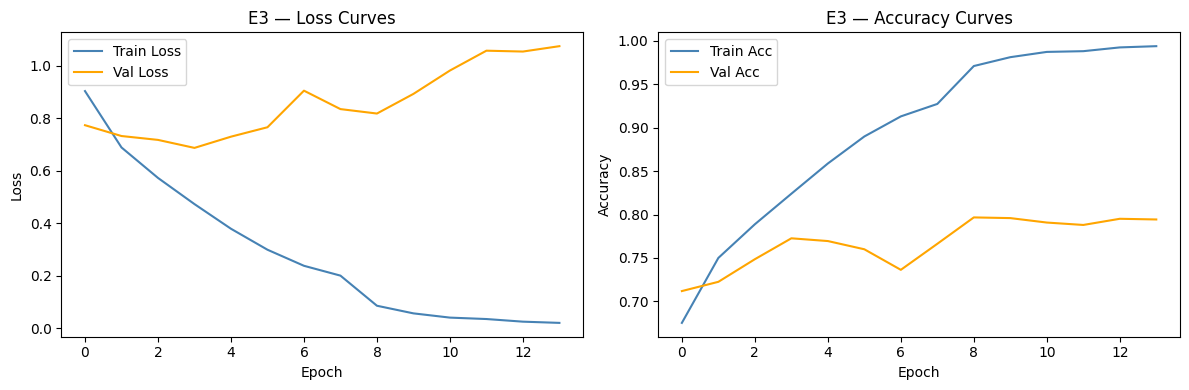

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses,   label='Val Loss',   color='orange')
axes[0].set_title('E3 — Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc', color='steelblue')
axes[1].plot(val_accs,   label='Val Acc',   color='orange')
axes[1].set_title('E3 — Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('e3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
model_e3.load_state_dict(torch.load('e3_best_model.pth'))
test_loss, test_acc = validate(model_e3, test_isic_loader, criterion, device)
print(f"E3 Test Accuracy (ISIC test set): {test_acc:.4f}")

E3 Test Accuracy (ISIC test set): 0.8035


In [30]:
# Build a new loader for PASSION test set with 9-class model
# We can't measure accuracy (class spaces don't match)
# so we measure confidence like E1

def evaluate_confidence_by_fitzpatrick(model, loader, device):
    model.eval()
    from collections import defaultdict
    fitz_confidences = defaultdict(list)
    all_confidences  = []

    with torch.no_grad():
        for images, labels, fitzpatricks in loader:
            images = images.to(device)
            outputs = model(images)
            probs   = F.softmax(outputs, dim=1)
            confidences, _ = torch.max(probs, dim=1)

            for conf, fitz in zip(confidences.cpu(), fitzpatricks):
                fitz_confidences[fitz.item()].append(conf.item())
                all_confidences.append(conf.item())

    avg_by_fitz = {
        fitz: sum(confs)/len(confs)
        for fitz, confs in sorted(fitz_confidences.items())
    }
    overall = sum(all_confidences) / len(all_confidences)
    return overall, avg_by_fitz

# Run on PASSION test set
overall_conf_e3, fitz_confs_e3 = evaluate_confidence_by_fitzpatrick(
    model_e3, test_loader, device
)

print("E3 — Confidence on PASSION test set (ISIC-trained model):")
print(f"Overall avg confidence: {overall_conf_e3:.4f}")
for fitz, conf in fitz_confs_e3.items():
    print(f"  Type {fitz}: {conf:.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


E3 — Confidence on PASSION test set (ISIC-trained model):
Overall avg confidence: 0.8622
  Type 3: 0.8605
  Type 4: 0.8389
  Type 5: 0.8751
  Type 6: 0.9096


In [31]:
import json

e3_results = {
    "experiment":        "E3",
    "model":             "MobileNetV3-Small",
    "pretrained_on":     "ImageNet",
    "trained_on":        "ISIC 2019 (25,331 images, 9 classes)",
    "evaluated_on":      "ISIC test set + PASSION test set",
    "num_classes":       9,
    "best_val_accuracy": 0.7967,
    "isic_test_accuracy": round(test_acc, 4),
    "passion_confidence": {
        "overall": round(overall_conf_e3, 4),
        "by_fitzpatrick": {str(k): round(v,4) for k,v in fitz_confs_e3.items()}
    },
    "notes": "Trained on Western dermatology data only. "
             "Evaluated on PASSION to measure generalisation to African skin."
}

with open('e3_results.json', 'w') as f:
    json.dump(e3_results, f, indent=2)

print(json.dumps(e3_results, indent=2))

{
  "experiment": "E3",
  "model": "MobileNetV3-Small",
  "pretrained_on": "ImageNet",
  "trained_on": "ISIC 2019 (25,331 images, 9 classes)",
  "evaluated_on": "ISIC test set + PASSION test set",
  "num_classes": 9,
  "best_val_accuracy": 0.7967,
  "isic_test_accuracy": 0.8035,
  "passion_confidence": {
    "overall": 0.8622,
    "by_fitzpatrick": {
      "3": 0.8605,
      "4": 0.8389,
      "5": 0.8751,
      "6": 0.9096
    }
  },
  "notes": "Trained on Western dermatology data only. Evaluated on PASSION to measure generalisation to African skin."
}


In [32]:

ISIC_TO_PASSION = {
    0: 3,   # MEL   -> Others
    1: 3,   # NV    -> Others
    2: 3,   # BCC   -> Others
    3: 3,   # AK    -> Others
    4: 3,   # BKL   -> Others
    5: 3,   # DF    -> Others
    6: 3,   # VASC  -> Others
    7: 3,   # SCC   -> Others
    8: 3,   # UNK   -> Others
}
# Note: ISIC has NO equivalent for Fungal(0), Scabies(1), Eczema(2)
# So the best this model can ever do is predict 'Others' for everything
# and only be correct for the ~12% of PASSION images labelled 'Others'

model_e3.eval()
correct = 0
total   = 0

with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(device)
        outputs = model_e3(images)
        preds   = outputs.argmax(dim=1).cpu()

        # Map all ISIC predictions to PASSION space
        mapped_preds = torch.tensor([ISIC_TO_PASSION[p.item()] for p in preds])
        correct += (mapped_preds == labels).sum().item()
        total   += labels.size(0)

e3_passion_acc = correct / total
print(f"E3 accuracy on PASSION test set: {e3_passion_acc:.4f}")
print(f"(Best possible if predicting 'Others' for everything: ~{189/(579+471+414+189):.4f})")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


E3 accuracy on PASSION test set: 0.1875
(Best possible if predicting 'Others' for everything: ~0.1143)
